In [1]:
import torch
import torch.nn as nn

from neural_network.trainer import NeuralNetworkTrainer
from neural_network.config import MarketParams, ModelConfig
from binomial_tree.binomial_tree import binomial_tree

In [2]:
r = 0.1
sigma = 0.4
K = 50
T = 1.0
S_min = 0.0
S_max = 3 * K

market_params = MarketParams(r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)

In [3]:
input_size = 2
hidden_sizes = [64, 64, 64]
output_size = 1
activation = nn.ReLU()
learning_rate = 0.001
model_config = ModelConfig(input_size=input_size,
                           hidden_sizes=hidden_sizes,
                           output_size=output_size,
                           activation=activation,
                           learning_rate=learning_rate
)

In [4]:
def payoff(S, K):
    return torch.relu(K - S)

In [5]:
trainer = NeuralNetworkTrainer(model_config, market_params, payoff, 123)
trainer.train(num_samples=1000, max_iterations=10000);

Iteration 0, Loss: 130.02793884277344
Iteration 100, Loss: 61.276268005371094
Iteration 200, Loss: 18.053787231445312
Iteration 300, Loss: 7.540919303894043
Iteration 400, Loss: 3.290919780731201
Iteration 500, Loss: 2.3379743099212646
Iteration 600, Loss: 0.9406025409698486
Iteration 700, Loss: 0.805128276348114
Converged at iteration 789


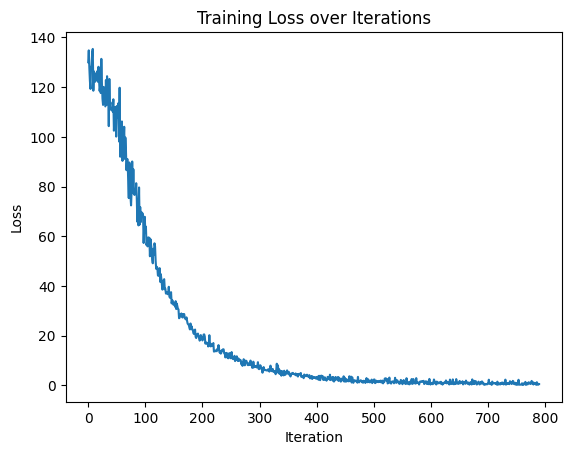

In [6]:
trainer.plot_losses()

In [7]:
trainer.predict(0, 50).item()

0.936515212059021

In [10]:
bt_price, _, _ = binomial_tree(S=K, K=K, T=T, r=r, sigma=sigma, n=1000)
print(bt_price)

5.978390989603648
